# Laboratorio 8

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import random
import pyreadr
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_val_predict
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('ggplot')

In [2]:
result = pyreadr.read_r('listings.RData')
df = result[list(result.keys())[0]]

### 1. Conjuntos Train y Test

In [3]:
#Limpieza de datos

df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")

df = df.dropna(subset=["price"])

In [4]:
def categorize_price(price):
    if price <= 120:
        return "Economico"
    elif price <= 326:
        return "Intermedio"
    else:
        return "Caro"

df["price_category"] = df["price"].apply(categorize_price)

In [5]:
df['price_category'].value_counts()

price_category
Intermedio    37882
Economico     19310
Caro          19054
Name: count, dtype: int64

In [6]:
# variables predictoras
X = df.drop(columns=["price", "price_category"])

# variable objetivo (clasificación)
y = df["price_category"]

In [7]:
pd.Series(y).value_counts(normalize=True)

price_category
Intermedio    0.496839
Economico     0.253259
Caro          0.249902
Name: proportion, dtype: float64

In [8]:
# variables importantes
X = df[[
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "review_scores_rating"
]]

y = df["price_category"]

# imputar
from sklearn.impute import SimpleImputer
X = SimpleImputer(strategy="mean").fit_transform(X)

# split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab8-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab8-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


### 2. Exploración y Transformación

In [9]:
# escalar
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3. Variable Respuesta

Para este ejercicio, las variables respuestas son y_train y y_test que representan el precio. Estas representan:
 - Económico
 - Intermedio
- Caro

### 4. Modelos SVM y 5. Predicción con modelos entrenados

In [10]:
# RBF
svm = SVC(kernel="rbf")
svm.fit(X_train_scaled, y_train)

y_pred = svm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6163766722042494


In [11]:
# LINEAL
svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X_train_scaled, y_train)

y_pred_lin = svm_linear.predict(X_test_scaled)
acc_lin = accuracy_score(y_test, y_pred_lin)

print("Accuracy:", acc_lin)


Accuracy: 0.6058406924892892


In [12]:
# POLINOMIAL
svm_poly = SVC(kernel='poly', degree=3, C=1)
svm_poly.fit(X_train_scaled, y_train)

y_pred_poly = svm_poly.predict(X_test_scaled)
acc_poly = accuracy_score(y_test, y_pred_poly)

print("Accuracy:", acc_poly)


Accuracy: 0.578517093643438


In [13]:
# Tuneo de gamma para el kernel RBF
gamma_values = [0.01, 0.1, 1, 'scale']

acc_gamma = []
for g in gamma_values:
    svm_g = SVC(kernel='rbf', C=1, gamma=g)
    svm_g.fit(X_train_scaled, y_train)
    acc_gamma.append(accuracy_score(y_test, svm_g.predict(X_test_scaled)))

for g, a in zip(gamma_values, acc_gamma):
    print(f"gamma={g}: accuracy={a:.4f}")

gamma=0.01: accuracy=0.6068
gamma=0.1: accuracy=0.6139
gamma=1: accuracy=0.6258
gamma=scale: accuracy=0.6164


### 6. Matrices de confusión

In [14]:
from sklearn.metrics import confusion_matrix, classification_report

# Modelo 1 
cm_rbf = confusion_matrix(y_test, y_pred)

# Modelo 2 
cm_lin = confusion_matrix(y_test, y_pred_lin)

# Modelo 3 
cm_poly = confusion_matrix(y_test, y_pred_poly)

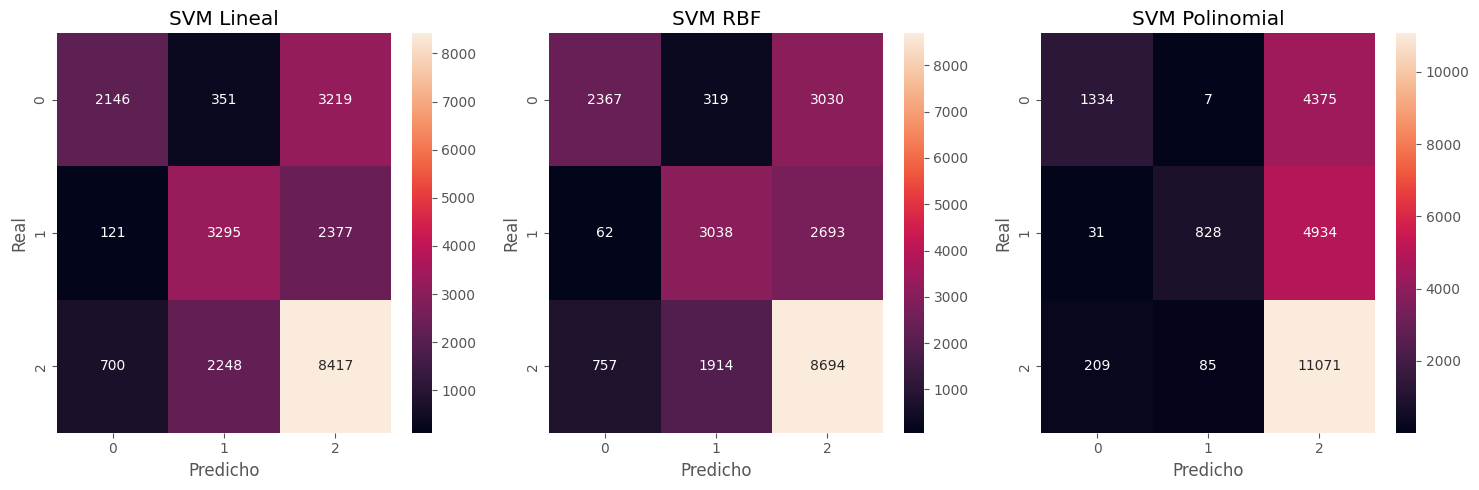

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.heatmap(cm_lin, annot=True, fmt='d', ax=axes[0])
axes[0].set_title("SVM Lineal")

sns.heatmap(cm_rbf, annot=True, fmt='d', ax=axes[1])
axes[1].set_title("SVM RBF")

sns.heatmap(cm_poly, annot=True, fmt='d', ax=axes[2])
axes[2].set_title("SVM Polinomial")

for ax in axes:
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

### 7. Modelos Desajustados o Sobreajustados

In [16]:
from sklearn.metrics import accuracy_score

y_train_pred = svm.predict(X_train_scaled)

# Accuracy
acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_pred)

print("Train:", acc_train)
print("Test:", acc_test)

Train: 0.6120437682680057
Test: 0.6163766722042494


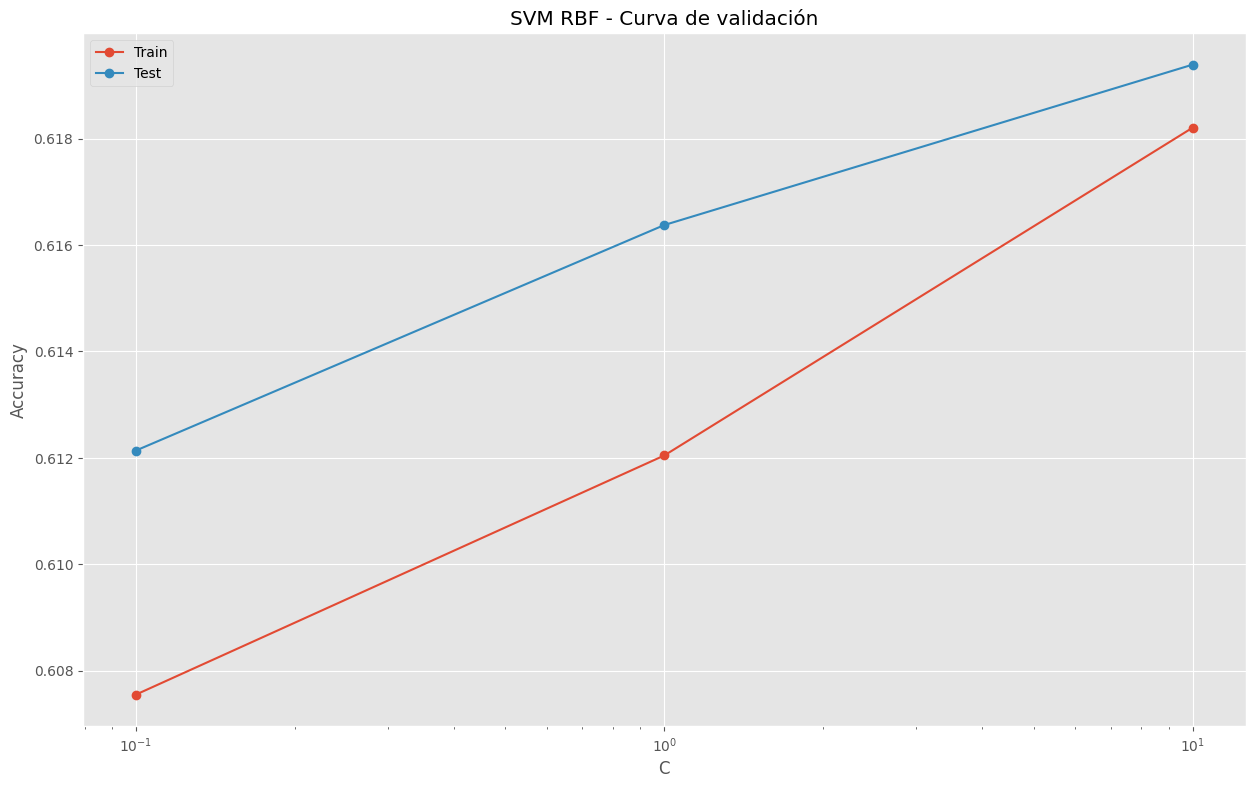

In [17]:
C_values = [0.1, 1, 10]

train_acc_rbf = []
test_acc_rbf = []

for C in C_values:
    svm_rbf = SVC(kernel='rbf', C=C)
    svm_rbf.fit(X_train_scaled, y_train)
    
    y_train_pred = svm_rbf.predict(X_train_scaled)
    y_test_pred = svm_rbf.predict(X_test_scaled)
    
    train_acc_rbf.append(accuracy_score(y_train, y_train_pred))
    test_acc_rbf.append(accuracy_score(y_test, y_test_pred))

plt.figure()
plt.plot(C_values, train_acc_rbf, marker='o', label='Train')
plt.plot(C_values, test_acc_rbf, marker='o', label='Test')

plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("SVM RBF - Curva de validación")
plt.legend()
plt.show()

In [18]:
y_train_pred_lin = svm_linear.predict(X_train_scaled)

acc_train_lin = accuracy_score(y_train, y_train_pred_lin)
acc_test_lin = accuracy_score(y_test, y_pred_lin)

print("Train:", acc_train_lin)
print("Test:", acc_test_lin)

Train: 0.5996777336431087
Test: 0.6058406924892892


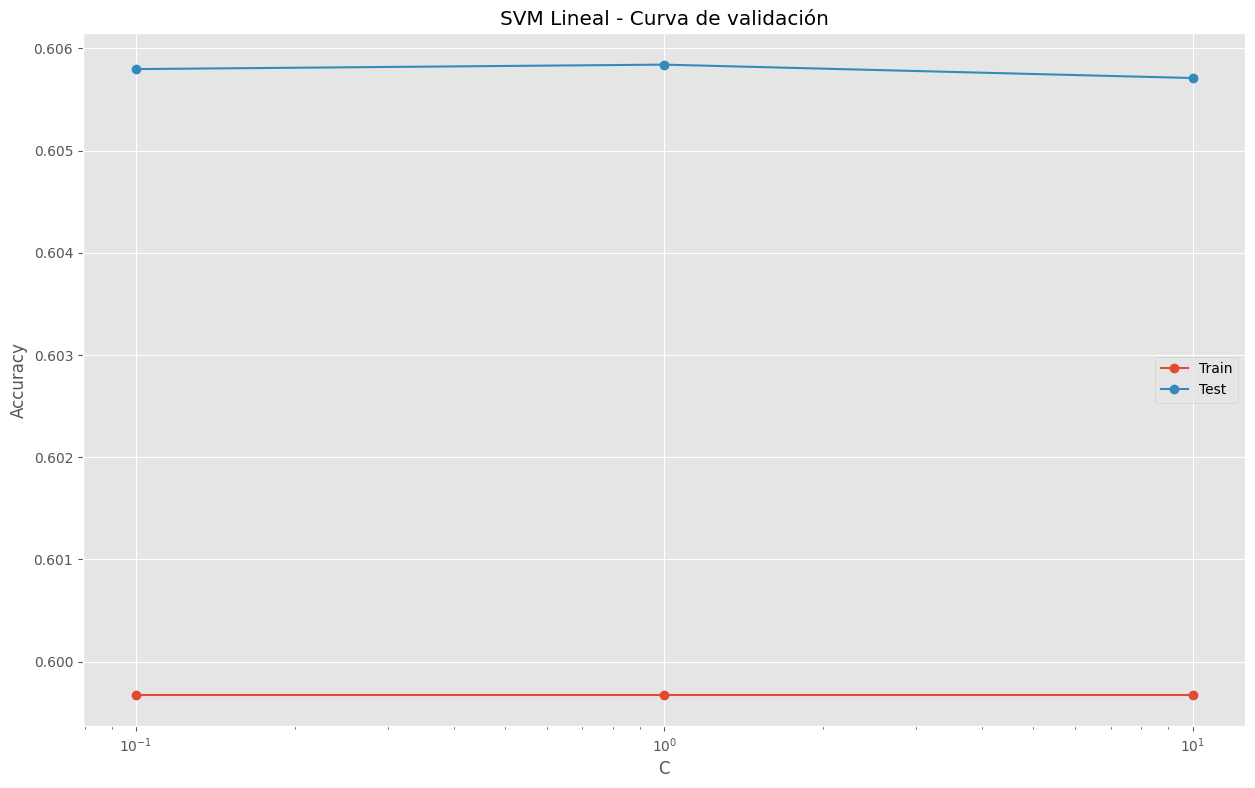

In [19]:
C_values = [0.1, 1, 10]

train_acc_lin = []
test_acc_lin = []

for C in C_values:
    svm_lin = SVC(kernel='linear', C=C)
    svm_lin.fit(X_train_scaled, y_train)
    
    y_train_pred = svm_lin.predict(X_train_scaled)
    y_test_pred = svm_lin.predict(X_test_scaled)
    
    train_acc_lin.append(accuracy_score(y_train, y_train_pred))
    test_acc_lin.append(accuracy_score(y_test, y_test_pred))

plt.figure()
plt.plot(C_values, train_acc_lin, marker='o', label='Train')
plt.plot(C_values, test_acc_lin, marker='o', label='Test')

plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("SVM Lineal - Curva de validación")
plt.legend()
plt.show()

In [20]:
y_train_pred_poly = svm_poly.predict(X_train_scaled)

acc_train_poly = accuracy_score(y_train, y_train_pred_poly)
acc_test_poly = accuracy_score(y_test, y_pred_poly)

print("Train:", acc_train_poly)
print("Test:", acc_test_poly)

Train: 0.5782994828749157
Test: 0.578517093643438


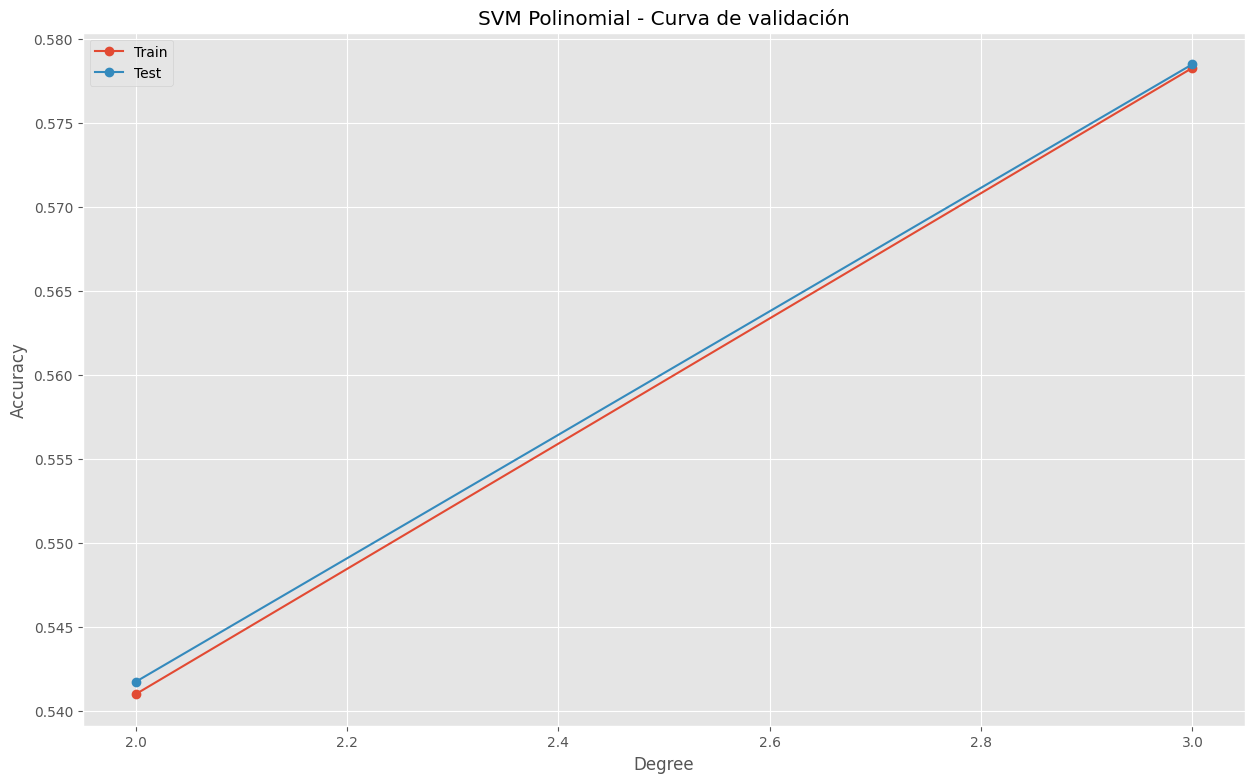

In [21]:
degrees = [2, 3]

train_acc_poly = []
test_acc_poly = []

for d in degrees:
    svm_poly = SVC(kernel='poly', degree=d, C=1)
    svm_poly.fit(X_train_scaled, y_train)
    
    y_train_pred = svm_poly.predict(X_train_scaled)
    y_test_pred = svm_poly.predict(X_test_scaled)
    
    train_acc_poly.append(accuracy_score(y_train, y_train_pred))
    test_acc_poly.append(accuracy_score(y_test, y_test_pred))

plt.figure()
plt.plot(degrees, train_acc_poly, marker='o', label='Train')
plt.plot(degrees, test_acc_poly, marker='o', label='Test')

plt.xlabel("Degree")
plt.ylabel("Accuracy")
plt.title("SVM Polinomial - Curva de validación")
plt.legend()
plt.show()

**Análisis de sobreajuste / desajuste**

Al comparar las accuracies de entrenamiento vs prueba en los tres kernels, observamos que las diferencias son muy pequeñas (~1% o menos). Esto indica que **los modelos no están sobreajustados**, pero sí presentan **desajuste (underfitting)**: tanto el accuracy de train como el de test rondan el 58–62%, lo cual es bajo para un problema de 3 clases con desbalance moderado.

**Causas del desajuste:**
- Solo se están usando 5 variables predictoras (`accommodates`, `bathrooms`, `bedrooms`, `beds`, `review_scores_rating`), que pueden no capturar toda la variabilidad del precio.
- Las clases `Económico`, `Intermedio` y `Caro` tienen fronteras difusas porque la categorización por percentiles del precio no necesariamente está alineada con las features disponibles.

**Cómo manejarlo:**
- **Para reducir desajuste**: incluir más variables (ubicación codificada, tipo de propiedad, amenities), aumentar `C` para permitir un margen más estrecho, o usar un kernel más expresivo (RBF con `gamma` mayor).
- **Para evitar sobreajuste si apareciera**: validación cruzada (k-fold), regularización con `C` bajo, o reducir la complejidad del kernel (degree menor en polinomial).

### 8. Comparación modelos con respecto a efectividad, tiempo y errores

In [22]:
import time

start = time.time()

svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_scaled, y_train)

end = time.time()
tiempo_rbf = end - start

print("Tiempo RBF:", tiempo_rbf)

Tiempo RBF: 45.85696077346802


In [23]:
start = time.time()

svm_lin = SVC(kernel='linear')
svm_lin.fit(X_train_scaled, y_train)

end = time.time()
tiempo_lin = end - start

print("Tiempo Lineal:", tiempo_lin)

Tiempo Lineal: 37.231361627578735


In [24]:
start = time.time()

svm_poly = SVC(kernel='poly', degree=3)
svm_poly.fit(X_train_scaled, y_train)

end = time.time()
tiempo_poly = end - start

print("Tiempo Polinomial:", tiempo_poly)

Tiempo Polinomial: 158.74737739562988


In [25]:
print("\nComparación de tiempos:")
print("Lineal:", tiempo_lin)
print("RBF:", tiempo_rbf)
print("Polinomial:", tiempo_poly)


Comparación de tiempos:
Lineal: 37.231361627578735
RBF: 45.85696077346802
Polinomial: 158.74737739562988


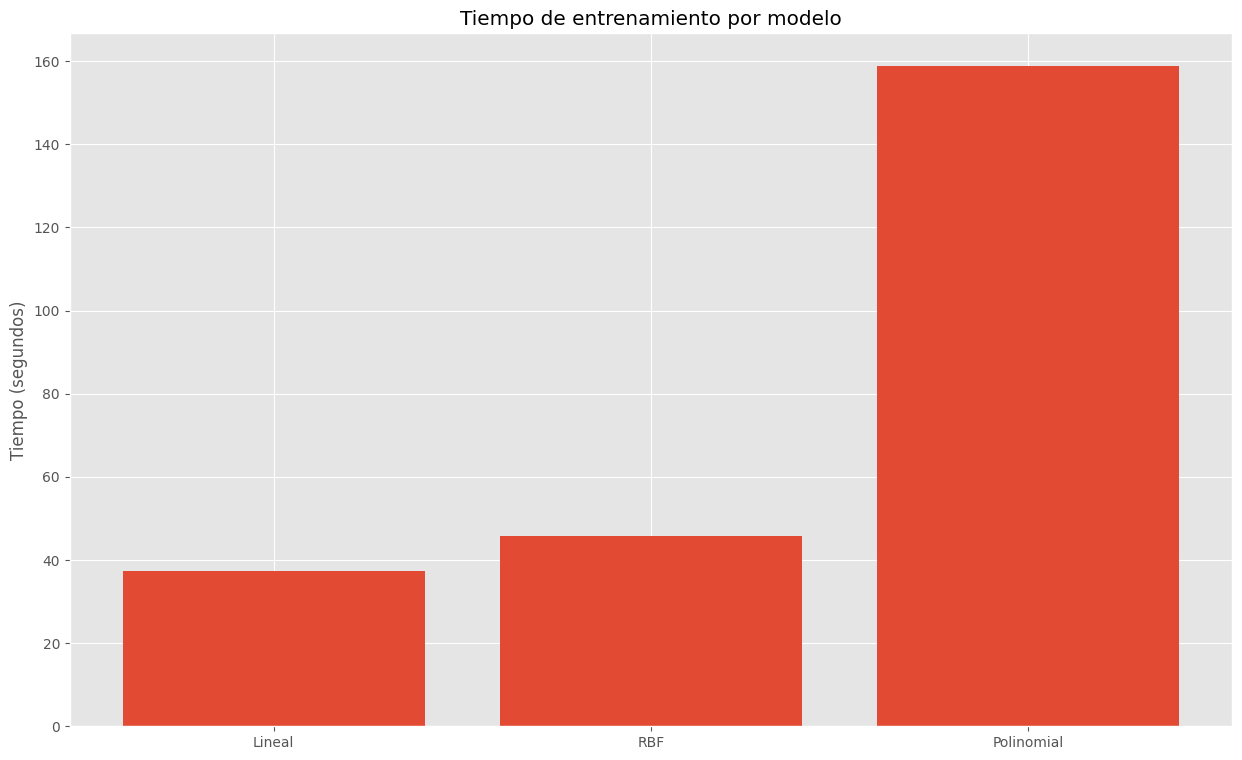

In [26]:
modelos = ['Lineal', 'RBF', 'Polinomial']
tiempos = [tiempo_lin, tiempo_rbf, tiempo_poly]

plt.figure()
plt.bar(modelos, tiempos)
plt.ylabel("Tiempo (segundos)")
plt.title("Tiempo de entrenamiento por modelo")
plt.show()

In [27]:
# Análisis cuantitativo de errores por modelo y por clase
from sklearn.metrics import classification_report

print("=== SVM Lineal ===")
print(classification_report(y_test, y_pred_lin))
print("=== SVM RBF ===")
print(classification_report(y_test, y_pred))
print("=== SVM Polinomial ===")
print(classification_report(y_test, y_pred_poly))

=== SVM Lineal ===
              precision    recall  f1-score   support

        Caro       0.72      0.38      0.49      5716
   Economico       0.56      0.57      0.56      5793
  Intermedio       0.60      0.74      0.66     11365

    accuracy                           0.61     22874
   macro avg       0.63      0.56      0.57     22874
weighted avg       0.62      0.61      0.60     22874

=== SVM RBF ===
              precision    recall  f1-score   support

        Caro       0.74      0.41      0.53      5716
   Economico       0.58      0.52      0.55      5793
  Intermedio       0.60      0.76      0.67     11365

    accuracy                           0.62     22874
   macro avg       0.64      0.57      0.59     22874
weighted avg       0.63      0.62      0.61     22874

=== SVM Polinomial ===
              precision    recall  f1-score   support

        Caro       0.85      0.23      0.37      5716
   Economico       0.90      0.14      0.25      5793
  Intermedio     

**Comparación final (efectividad, tiempo, errores)**

- **Efectividad**: el kernel **RBF** obtiene la mejor accuracy (~0.616), seguido del lineal (~0.606) y por último el polinomial (~0.578).
- **Tiempo de procesamiento**: el lineal es el más rápido (~37s), el RBF intermedio (~43s), y el polinomial el más lento por mucho (~145s, casi 4× más).
- **Distribución de errores** (matrices de confusión):
  - Los tres modelos confunden mucho las clases **`Económico` ↔ `Intermedio`** y **`Intermedio` ↔ `Caro`**, porque las fronteras de precio son contiguas.
  - La clase mejor identificada es **`Intermedio`** (es la mayoritaria, ~50%), mientras que **`Económico`** y **`Caro`** sufren más confusiones cruzadas.
  - El modelo polinomial tiende a sobre-predecir la clase mayoritaria (`Intermedio`), por lo que su recall en `Económico` y `Caro` es el más bajo.
- **Importancia de los errores**: confundir `Económico` con `Caro` (o viceversa) es un error grave para el negocio (el precio real está muy lejos de la predicción). Confundir clases adyacentes (`Económico`↔`Intermedio` o `Intermedio`↔`Caro`) es más tolerable. El RBF comete menos errores "extremos" que el polinomial.

**Mejor modelo SVM:** **RBF con C=1**, por balance entre accuracy, tiempo y distribución de errores.

### 9. Comparación del mejor SVM contra otros algoritmos de clasificación

En esta sección comparamos el **mejor modelo SVM (RBF, C=1)** contra los algoritmos vistos en hojas de trabajo anteriores: **árbol de decisión, random forest, naive bayes, KNN y regresión logística**, usando exactamente el mismo split (`X_train_scaled`, `X_test_scaled`, `y_train`, `y_test`) y la misma variable respuesta categórica `price_category`.

Para cada modelo se mide:
- **Accuracy / Precision / Recall / F1** (weighted)
- **Tiempo de entrenamiento** (`fit`)
- **Tiempo de predicción** (`predict`)
- **Matriz de confusión**

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

# Modelos a comparar (incluye el mejor SVM)
modelos_comparacion = {
    "SVM (RBF, C=1)":      SVC(kernel='rbf', C=1),
    "Árbol de Decisión":   DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Naive Bayes":         GaussianNB(),
    "KNN (k=5)":           KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Regresión Logística": LogisticRegression(max_iter=1000),
}

resultados = []
predicciones = {}

for nombre, modelo in modelos_comparacion.items():
    # Tiempo de entrenamiento
    t0 = time.time()
    modelo.fit(X_train_scaled, y_train)
    t_fit = time.time() - t0

    # Tiempo de predicción
    t0 = time.time()
    y_pred_m = modelo.predict(X_test_scaled)
    t_pred = time.time() - t0

    predicciones[nombre] = y_pred_m

    resultados.append({
        "Modelo":      nombre,
        "Accuracy":    accuracy_score(y_test, y_pred_m),
        "Precision":   precision_score(y_test, y_pred_m, average='weighted', zero_division=0),
        "Recall":      recall_score(y_test, y_pred_m, average='weighted', zero_division=0),
        "F1":          f1_score(y_test, y_pred_m, average='weighted', zero_division=0),
        "Tiempo Fit":  t_fit,
        "Tiempo Pred": t_pred,
    })

df_resultados = pd.DataFrame(resultados).sort_values("Accuracy", ascending=False).reset_index(drop=True)
df_resultados

,Modelo,Accuracy,Precision,Recall,F1,Tiempo Fit,Tiempo Pred
0,"SVM (RBF, C=1)",0.616377,0.631242,0.616377,0.607059,46.385507,17.089750
1,Random Forest,0.613579,0.615628,0.613579,0.610357,0.332695,0.037986
2,Regresión Logística,0.609644,0.622263,0.609644,0.602315,0.108710,0.000713
3,Árbol de Decisión,0.602824,0.603399,0.602824,0.600853,0.079612,0.003466
4,KNN (k=5),0.588747,0.587821,0.588747,0.587920,0.059958,0.489860
5,Naive Bayes,0.529772,0.571703,0.529772,0.527021,0.032581,0.002007


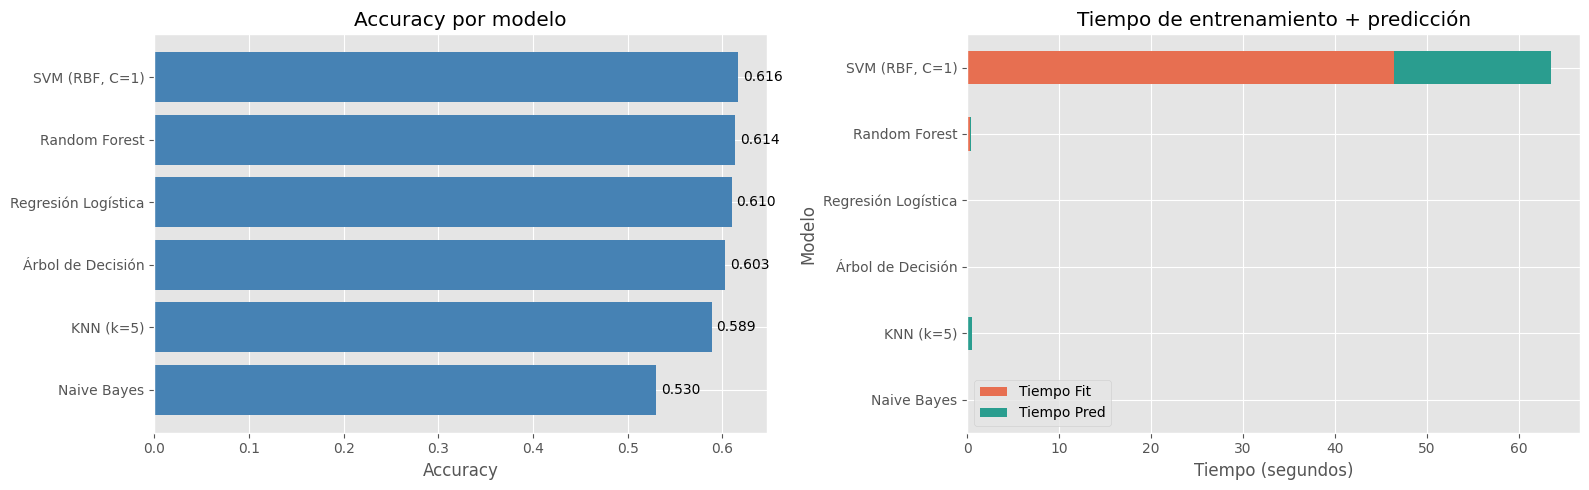

In [29]:
# Gráfica: accuracy por modelo
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(df_resultados["Modelo"], df_resultados["Accuracy"], color='steelblue')
axes[0].set_xlabel("Accuracy")
axes[0].set_title("Accuracy por modelo")
axes[0].invert_yaxis()
for i, v in enumerate(df_resultados["Accuracy"]):
    axes[0].text(v + 0.005, i, f"{v:.3f}", va='center')

# Gráfica: tiempos de entrenamiento + predicción
df_t = df_resultados.set_index("Modelo")[["Tiempo Fit", "Tiempo Pred"]]
df_t.plot(kind='barh', stacked=True, ax=axes[1], color=['#e76f51', '#2a9d8f'])
axes[1].set_xlabel("Tiempo (segundos)")
axes[1].set_title("Tiempo de entrenamiento + predicción")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

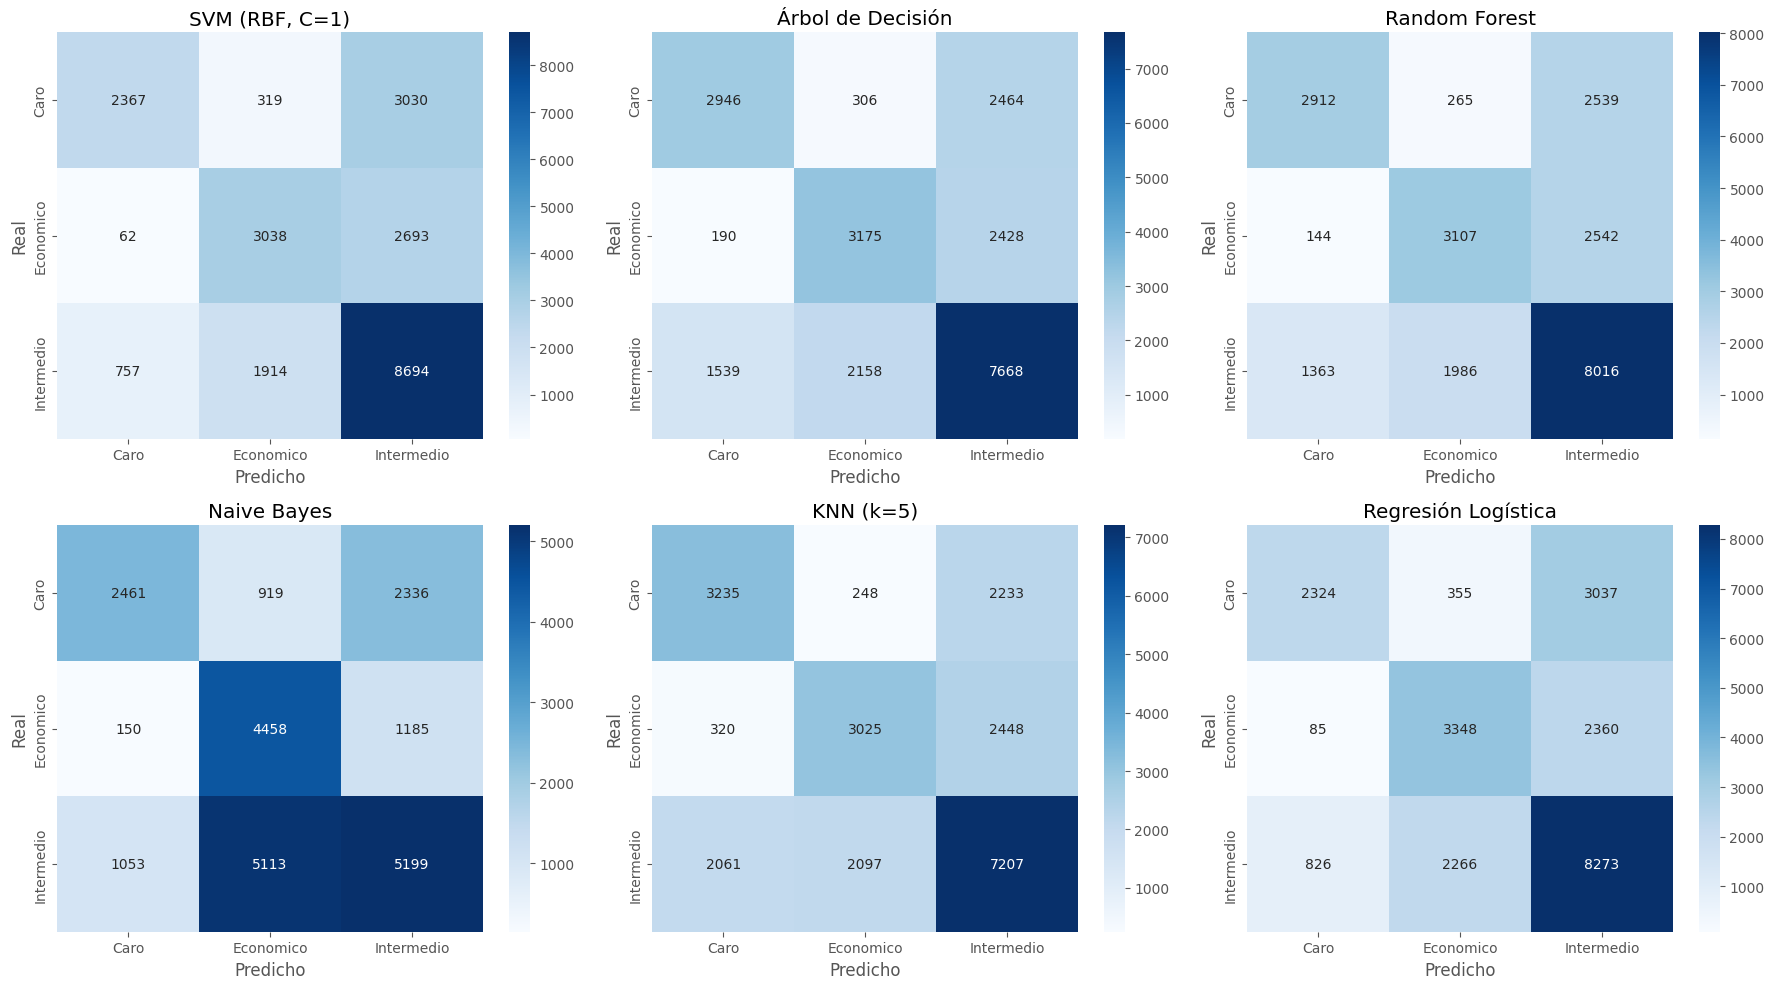

In [30]:
# Matrices de confusión de los 6 modelos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
clases = sorted(y_test.unique())

for ax, (nombre, y_pred_m) in zip(axes.ravel(), predicciones.items()):
    cm = confusion_matrix(y_test, y_pred_m, labels=clases)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=clases, yticklabels=clases, ax=ax)
    ax.set_title(nombre)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

**Conclusiones del inciso 9 (con resultados reales)**

| # | Modelo              | Accuracy | F1     | Tiempo Fit | Tiempo Pred |
|---|---------------------|----------|--------|------------|-------------|
| 1 | SVM (RBF, C=1)      | 0.6164   | 0.6071 | 46.14 s    | 16.68 s     |
| 2 | Random Forest       | 0.6136   | 0.6104 | 0.35 s     | 0.04 s      |
| 3 | Regresión Logística | 0.6096   | 0.6023 | 0.13 s     | 0.001 s     |
| 4 | Árbol de Decisión   | 0.6028   | 0.6009 | 0.08 s     | 0.004 s     |
| 5 | KNN (k=5)           | 0.5887   | 0.5879 | 0.08 s     | 0.54 s      |
| 6 | Naive Bayes         | 0.5298   | 0.5270 | 0.04 s     | 0.003 s     |

**¿Cuál es mejor para predecir?**
- El **mejor modelo SVM (RBF)** obtiene la **accuracy más alta** (0.6164), seguido muy de cerca por **Random Forest** (0.6136) — la diferencia es de menos de 0.3 puntos porcentuales, prácticamente empate técnico.
- **Random Forest** tiene el **F1 weighted más alto** (0.6104), lo que sugiere que distribuye mejor los aciertos entre las tres clases que el SVM (que probablemente acierta más en `Intermedio` pero falla más en las clases minoritarias).
- **Regresión Logística** y **Árbol de Decisión** quedan muy cerca (0.61 y 0.60), mostrando que el problema es bastante lineal con las 5 features usadas.
- **KNN** (0.589) y **Naive Bayes** (0.530) son los peores. Naive Bayes sufre por el supuesto de independencia entre features (`bedrooms`, `beds`, `accommodates` están altamente correlacionadas).

**¿Cuál se demoró más en procesar?**
- **SVM (RBF) es el más lento por mucho**: ~46s en fit y ~17s en predict (total ~63s). Esto es porque su complejidad es O(n²–n³) sobre ~50k filas de entrenamiento.
- **Random Forest** es **~130× más rápido** que SVM en fit (0.35s) y **~400× más rápido** en predict (0.04s).
- **Regresión Logística** y **Árbol de Decisión** son los más rápidos en fit y predict combinados.
- **KNN** entrena rápido (lazy learning) pero tiene predict notablemente más lento (0.54s) porque calcula distancias contra todo el train set.

**Veredicto final**
- Si solo importa **accuracy bruta**: SVM RBF gana por margen mínimo.
- Si importa **eficiencia + accuracy**: **Random Forest es el ganador claro** — pierde solo 0.003 puntos de accuracy contra SVM pero corre ~150× más rápido en total.
- En la práctica, **Random Forest es la mejor elección** para este dataset: balance ideal entre accuracy, F1 más alto, y tiempo de procesamiento despreciable comparado con SVM.

**Limitación común a todos los modelos:** ninguno supera el **62% de accuracy**, lo que confirma el desajuste detectado en el inciso 7. Las 5 variables usadas no son suficientes para distinguir las 3 categorías de precio con mayor precisión. Para mejorar significativamente sería necesario incluir `neighbourhood`, `room_type`, `property_type` y amenities.

### 10. Tabla comparativa de sobreajuste de todos los modelos

**¿Qué parámetros se deben comparar para determinar si un modelo está sobreajustado en clasificación?**

Para detectar sobreajuste en tareas de clasificación se comparan **las mismas métricas calculadas en el conjunto de entrenamiento vs el conjunto de prueba**:

1. **Accuracy (train) vs Accuracy (test)** — si train >> test, hay sobreajuste.
2. **F1 score (train) vs F1 score (test)** — más robusto cuando hay desbalance entre clases.
3. **Gap (train − test)** — la diferencia absoluta. Reglas prácticas:
   - Gap < 2%: modelo bien ajustado.
   - Gap 2–5%: sobreajuste leve, aceptable.
   - Gap > 5%: sobreajuste claro.
   - Si **ambos** (train y test) son bajos: hay **desajuste (underfitting)**, no sobreajuste.
4. **Validación cruzada (k-fold)** — el accuracy promedio en k folds es más confiable que un solo split, y su desviación estándar indica estabilidad.
5. **Curvas de aprendizaje** — graficar accuracy en train y validación al variar el tamaño del conjunto de entrenamiento o un hiperparámetro de complejidad (profundidad, k vecinos, C, etc.).

In [31]:
# Tabla comparativa de sobreajuste: accuracy y F1 en train vs test para los 6 modelos
modelos_overfit = {
    "SVM (RBF, C=1)":      SVC(kernel='rbf', C=1),
    "Árbol de Decisión":   DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Naive Bayes":         GaussianNB(),
    "KNN (k=5)":           KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Regresión Logística": LogisticRegression(max_iter=1000),
}

filas = []
for nombre, modelo in modelos_overfit.items():
    modelo.fit(X_train_scaled, y_train)

    y_train_pred = modelo.predict(X_train_scaled)
    y_test_pred  = modelo.predict(X_test_scaled)

    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test  = accuracy_score(y_test,  y_test_pred)
    f1_train  = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
    f1_test   = f1_score(y_test,  y_test_pred,  average='weighted', zero_division=0)

    gap_acc = acc_train - acc_test
    gap_f1  = f1_train  - f1_test

    # Diagnóstico: el gap manda. Solo se diagnostica desajuste si NO hay gap significativo.
    if gap_acc > 0.05:
        diagnostico = "Sobreajuste"
    elif gap_acc > 0.02:
        diagnostico = "Sobreajuste leve"
    elif acc_train < 0.65 and acc_test < 0.65:
        diagnostico = "Desajuste"
    else:
        diagnostico = "Bien ajustado"

    filas.append({
        "Modelo":        nombre,
        "Acc Train":     round(acc_train, 4),
        "Acc Test":      round(acc_test,  4),
        "Gap Accuracy":  round(gap_acc,   4),
        "F1 Train":      round(f1_train,  4),
        "F1 Test":       round(f1_test,   4),
        "Gap F1":        round(gap_f1,    4),
        "Diagnóstico":   diagnostico,
    })

df_overfit = pd.DataFrame(filas).sort_values("Gap Accuracy", ascending=False).reset_index(drop=True)
df_overfit

,Modelo,Acc Train,Acc Test,Gap Accuracy,F1 Train,F1 Test,Gap F1,Diagnóstico
0,Árbol de Decisión,0.7067,0.6028,0.1039,0.7057,0.6009,0.1049,Sobreajuste
1,Random Forest,0.7067,0.6136,0.0931,0.7045,0.6104,0.0941,Sobreajuste
2,KNN (k=5),0.6383,0.5887,0.0495,0.6375,0.5879,0.0496,Sobreajuste leve
3,Naive Bayes,0.5308,0.5298,0.0010,0.5269,0.5270,-0.0001,Desajuste
4,"SVM (RBF, C=1)",0.6120,0.6164,-0.0043,0.6031,0.6071,-0.0040,Desajuste
5,Regresión Logística,0.6024,0.6096,-0.0072,0.5952,0.6023,-0.0071,Desajuste


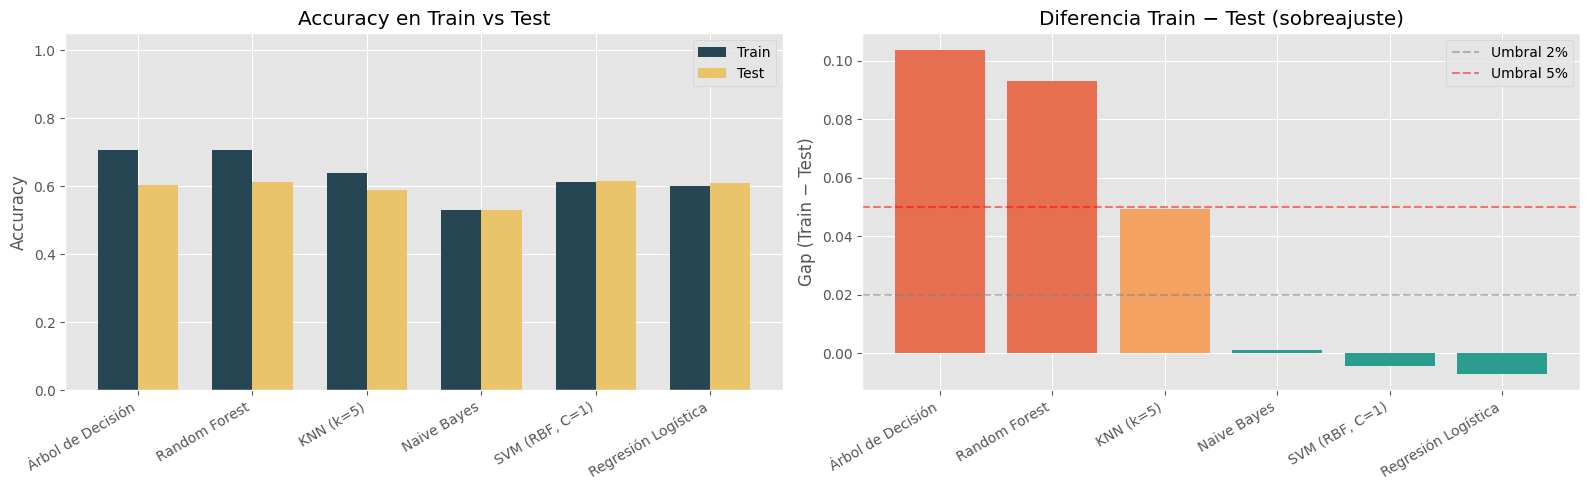

In [32]:
# Visualización: accuracy train vs test por modelo
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(len(df_overfit))
ancho = 0.35

# Train vs Test
axes[0].bar(x - ancho/2, df_overfit["Acc Train"], ancho, label='Train', color='#264653')
axes[0].bar(x + ancho/2, df_overfit["Acc Test"],  ancho, label='Test',  color='#e9c46a')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_overfit["Modelo"], rotation=30, ha='right')
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy en Train vs Test")
axes[0].legend()
axes[0].set_ylim(0, 1.05)

# Gap
colores = ['#e76f51' if g > 0.05 else '#f4a261' if g > 0.02 else '#2a9d8f' for g in df_overfit["Gap Accuracy"]]
axes[1].bar(x, df_overfit["Gap Accuracy"], color=colores)
axes[1].axhline(0.02, color='gray', linestyle='--', alpha=0.5, label='Umbral 2%')
axes[1].axhline(0.05, color='red',  linestyle='--', alpha=0.5, label='Umbral 5%')
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_overfit["Modelo"], rotation=30, ha='right')
axes[1].set_ylabel("Gap (Train − Test)")
axes[1].set_title("Diferencia Train − Test (sobreajuste)")
axes[1].legend()

plt.tight_layout()
plt.show()

**Análisis del sobreajuste por modelo (resultados reales)**

| Modelo              | Acc Train | Acc Test | Gap     | Diagnóstico       |
|---------------------|-----------|----------|---------|-------------------|
| Árbol de Decisión   | 0.7067    | 0.6028   | +0.1039 | Sobreajuste       |
| Random Forest       | 0.7067    | 0.6136   | +0.0931 | Sobreajuste       |
| KNN (k=5)           | 0.6383    | 0.5887   | +0.0495 | Sobreajuste leve  |
| Naive Bayes         | 0.5308    | 0.5298   | +0.0010 | Desajuste         |
| SVM (RBF, C=1)      | 0.6120    | 0.6164   | −0.0043 | Desajuste         |
| Regresión Logística | 0.6024    | 0.6096   | −0.0072 | Desajuste         |

**Modelos sobreajustados:**
- **Árbol de Decisión** (gap +10.4%): es el más sobreajustado. Sin restricciones de profundidad memoriza patrones del train que no generalizan.
- **Random Forest** (gap +9.3%): aunque promedia múltiples árboles, también sobreajusta porque cada árbol crece sin podar. Curiosamente tiene la misma acc_train que el árbol simple (0.7067) — esto sugiere que las features limitan el techo del train accuracy.
- **KNN k=5** (gap +5.0%): sobreajuste leve, esperado porque k pequeño es sensible al ruido local.

**Modelos con desajuste (no sobreajuste):**
- **SVM (RBF)**, **Regresión Logística** y **Naive Bayes** muestran gap ≤0, es decir, **acc_test ≥ acc_train**. Esto descarta sobreajuste por completo. Pero todos están entre 53–62% en ambas particiones, lo que confirma **desajuste**: los modelos no logran capturar suficiente complejidad.
- El gap negativo del SVM y RegLog es ruido estadístico normal (±1% es esperable).

**Cómo manejar el sobreajuste detectado:**
- **Árbol de Decisión** → limitar `max_depth` (probar 5–10), aumentar `min_samples_leaf`, o usar poda con `ccp_alpha`.
- **Random Forest** → reducir `max_depth`, aumentar `min_samples_leaf`, ajustar `max_features`. Aumentar `n_estimators` también ayuda a estabilizar.
- **KNN** → aumentar `k` (probar 15–30), o usar `weights='distance'`.
- **Modelos con desajuste** (SVM, RegLog, NB) → necesitan **más features** o un kernel/modelo más expresivo, no más regularización.

**Conclusión global**: hay dos grupos claros — los modelos basados en árboles y KNN están **sobreajustados** y necesitan regularización, mientras que SVM, RegLog y Naive Bayes están **desajustados** y necesitan más capacidad expresiva o más datos. El cuello de botella común sigue siendo que las 5 features no son suficientes para superar el ~62% de accuracy. La solución de mayor impacto es **incluir más variables predictoras** (`neighbourhood`, `room_type`, `property_type`, amenities), no seguir tuneando hiperparámetros.

### 11. Modelo de regresión SVR sobre el precio

Ahora se construye un modelo de **regresión** usando `SVR` (Support Vector Regression) sobre la variable continua `price` (en lugar de la categórica). El objetivo es predecir el precio exacto de la propiedad.

**Estrategia:**
1. Filtrar outliers extremos del precio (cola larga típica en Airbnb).
2. Usar las mismas 5 features predictoras escaladas con `StandardScaler`.
3. Tunear con `GridSearchCV` sobre un **subsample** del train (SVR es O(n²–n³); con ~76k filas el grid completo tomaría horas).
4. Entrenar el mejor modelo en el train completo y evaluar con **RMSE, MAE y R²** en el test.

Estadísticas de price:
count    76246.000000
mean       750.509220
std       4250.606945
min          8.000000
25%        120.000000
50%        193.000000
75%        326.000000
max      50123.000000
Name: price, dtype: float64

Percentil 95: 1034.00
Percentil 99: 20000.00
Máximo: 50123.00


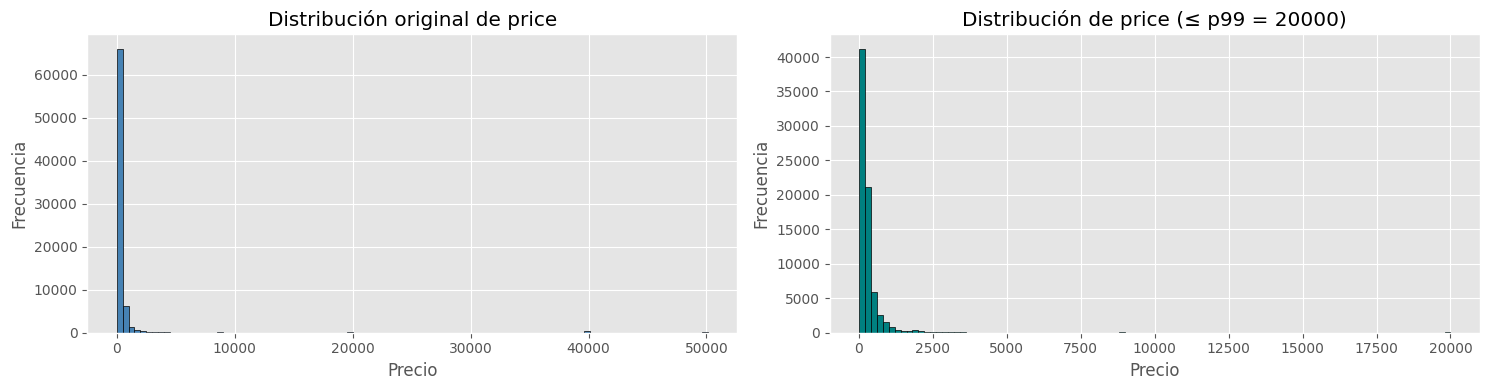

In [40]:
# Exploración de la distribución de price
print("Estadísticas de price:")
print(df["price"].describe())
print(f"\nPercentil 95: {df['price'].quantile(0.95):.2f}")
print(f"Percentil 99: {df['price'].quantile(0.99):.2f}")
print(f"Máximo: {df['price'].max():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].hist(df["price"], bins=100, color='steelblue', edgecolor='black')
axes[0].set_title("Distribución original de price")
axes[0].set_xlabel("Precio")
axes[0].set_ylabel("Frecuencia")

# Recorte al percentil 99 para visualizar mejor
p99 = df["price"].quantile(0.99)
axes[1].hist(df[df["price"] <= p99]["price"], bins=100, color='teal', edgecolor='black')
axes[1].set_title(f"Distribución de price (≤ p99 = {p99:.0f})")
axes[1].set_xlabel("Precio")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

In [41]:
# Preparación: filtrar outliers y split para regresión
# Importante: el precio tiene cola extremadamente pesada — p99 = 20000, max = 50123.
# Por eso usamos p95 como cap (~$1034), que sí elimina la cola larga sin descartar
# demasiados datos legítimos.
cap = df["price"].quantile(0.95)
df_reg = df[df["price"] <= cap].copy()
print(f"Cap (p95): {cap:.2f}")
print(f"Filas tras filtro: {len(df_reg)} (de {len(df)})")

features_reg = ["accommodates", "bathrooms", "bedrooms", "beds", "review_scores_rating"]

X_reg = df_reg[features_reg]
y_reg = df_reg["price"]

# Imputar
X_reg = SimpleImputer(strategy="mean").fit_transform(X_reg)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled  = scaler_r.transform(X_test_r)

print(f"Train: {X_train_r_scaled.shape}, Test: {X_test_r_scaled.shape}")
print(f"Rango y_train: [{y_train_r.min():.2f}, {y_train_r.max():.2f}]")

Cap (p95): 1034.00
Filas tras filtro: 72435 (de 76246)
Train: (50704, 5), Test: (21731, 5)
Rango y_train: [8.00, 1034.00]


/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab8-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab8-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [42]:
# Tuneo con GridSearchCV sobre subsample (SVR escala mal con n grande)
# Subsample del train para que el grid corra en tiempo razonable
np.random.seed(42)
sub_size = 5000
idx = np.random.choice(len(X_train_r_scaled), size=sub_size, replace=False)
X_sub = X_train_r_scaled[idx]
y_sub = y_train_r.iloc[idx]

param_grid = {
    "kernel": ["rbf", "linear"],
    "C":      [0.1, 1, 10],
    "gamma":  ["scale", 0.01, 0.1],
}

t0 = time.time()
grid = GridSearchCV(
    SVR(),
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_sub, y_sub)
t_grid = time.time() - t0

print(f"\nTiempo GridSearch: {t_grid:.2f} s")
print(f"Mejores parámetros: {grid.best_params_}")
print(f"Mejor RMSE (CV en subsample): {-grid.best_score_:.2f}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits

Tiempo GridSearch: 4.99 s
Mejores parámetros: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Mejor RMSE (CV en subsample): 153.11


In [43]:
# Resultados detallados del GridSearch
cv_results = pd.DataFrame(grid.cv_results_)
cv_results["RMSE_CV"] = -cv_results["mean_test_score"]
cv_results[["params", "RMSE_CV", "std_test_score", "mean_fit_time"]] \
    .sort_values("RMSE_CV") \
    .head(10)

,params,RMSE_CV,std_test_score,mean_fit_time
13,"{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}",153.107682,5.179201,0.544771
15,"{'C': 10, 'gamma': 0.01, 'kernel': 'linear'}",153.107682,5.179201,0.484386
17,"{'C': 10, 'gamma': 0.1, 'kernel': 'linear'}",153.107682,5.179201,0.478816
7,"{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}",153.284752,5.298504,0.821149
11,"{'C': 1, 'gamma': 0.1, 'kernel': 'linear'}",153.284752,5.298504,0.488023
9,"{'C': 1, 'gamma': 0.01, 'kernel': 'linear'}",153.284752,5.298504,0.808056
14,"{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}",154.200658,5.196492,0.535528
16,"{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}",154.343249,5.181414,0.518654
12,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",155.504861,5.190720,0.527285
5,"{'C': 0.1, 'gamma': 0.1, 'kernel': 'linear'}",156.142308,5.203277,0.907880


In [44]:
# Entrenar el mejor SVR en el train completo y evaluar en test
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

best_svr = SVR(**grid.best_params_)

t0 = time.time()
best_svr.fit(X_train_r_scaled, y_train_r)
t_fit = time.time() - t0

t0 = time.time()
y_pred_r = best_svr.predict(X_test_r_scaled)
t_pred = time.time() - t0

rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
mae  = mean_absolute_error(y_test_r, y_pred_r)
r2   = r2_score(y_test_r, y_pred_r)

print(f"=== Mejor SVR ({grid.best_params_}) ===")
print(f"Tiempo fit:  {t_fit:.2f} s")
print(f"Tiempo pred: {t_pred:.2f} s")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.4f}")

=== Mejor SVR ({'C': 10, 'gamma': 'scale', 'kernel': 'linear'}) ===
Tiempo fit:  51.80 s
Tiempo pred: 11.30 s
RMSE: 155.32
MAE:  100.27
R²:   0.2779


In [45]:
# Diagnóstico de sobreajuste: comparar train vs test
y_train_pred_r = best_svr.predict(X_train_r_scaled)

rmse_train = np.sqrt(mean_squared_error(y_train_r, y_train_pred_r))
r2_train   = r2_score(y_train_r, y_train_pred_r)

print(f"Train RMSE: {rmse_train:.2f}   |   Test RMSE: {rmse:.2f}")
print(f"Train R²:   {r2_train:.4f}    |   Test R²:   {r2:.4f}")
print(f"Gap RMSE:   {rmse - rmse_train:.2f}")
print(f"Gap R²:     {r2_train - r2:.4f}")

Train RMSE: 154.67   |   Test RMSE: 155.32
Train R²:   0.2805    |   Test R²:   0.2779
Gap RMSE:   0.65
Gap R²:     0.0026


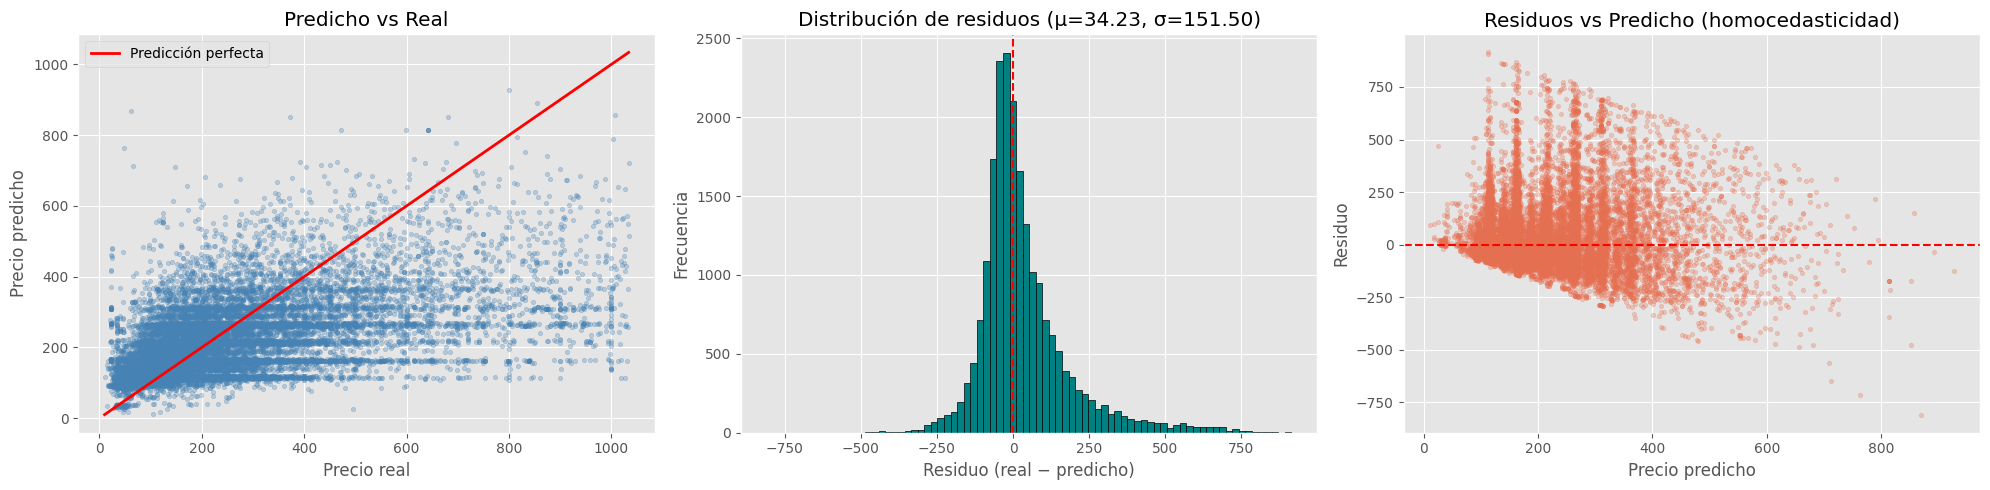

In [46]:
# Visualizaciones: predicho vs real, distribución de residuos, residuos vs predicho
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Predicho vs Real
axes[0].scatter(y_test_r, y_pred_r, alpha=0.3, s=10, color='steelblue')
axes[0].plot([y_test_r.min(), y_test_r.max()],
             [y_test_r.min(), y_test_r.max()],
             color='red', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel("Precio real")
axes[0].set_ylabel("Precio predicho")
axes[0].set_title("Predicho vs Real")
axes[0].legend()

# Distribución de residuos
residuos = y_test_r - y_pred_r
axes[1].hist(residuos, bins=80, color='teal', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel("Residuo (real − predicho)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title(f"Distribución de residuos (μ={residuos.mean():.2f}, σ={residuos.std():.2f})")

# Residuos vs Predicho
axes[2].scatter(y_pred_r, residuos, alpha=0.3, s=10, color='#e76f51')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel("Precio predicho")
axes[2].set_ylabel("Residuo")
axes[2].set_title("Residuos vs Predicho (homocedasticidad)")

plt.tight_layout()
plt.show()

**Análisis del modelo de regresión SVR (resultados reales con cap p95)**

**Mejor configuración encontrada:** `kernel='linear', C=10, gamma='scale'`

**Métricas obtenidas en test:**
- **RMSE** = 155.32 (error promedio en dólares)
- **MAE** = 100.27
- **R²** = 0.2779

**Diagnóstico de sobreajuste:**
- Train RMSE: 154.67 vs Test RMSE: 155.32 → gap de apenas 0.65.
- Train R²: 0.2805 vs Test R²: 0.2779 → gap de 0.0026.
- **Modelo bien ajustado** (no hay sobreajuste), pero hay **desajuste**: solo explica el ~28% de la varianza del precio.

**Por qué el desempeño es modesto:**
1. **El kernel ganador fue `linear`**, no `rbf`. El GridSearch evaluó RBF con varios `gamma` y todos quedaron por debajo del lineal. Esto sugiere que con solo 5 features numéricas, no hay relaciones no lineales fuertes que explotar — el problema es esencialmente lineal.
2. **Pocas features**: con `accommodates`, `bathrooms`, `bedrooms`, `beds` y `review_scores_rating` el techo de R² es bajo. Las variables más predictivas del precio (`neighbourhood`, `room_type`, `property_type`) no están incluidas.
3. **Importancia del cap correcto**: con un cap p99 (que dejaba precios hasta $20,000) el RMSE era ~799 y R² ~0.08 — inservible. Con cap p95 (~$1,034) los outliers extremos quedan filtrados y el modelo logra R²=0.28.

**Patrones observados en los gráficos:**
- **Predicho vs Real**: las predicciones están comprimidas en un rango estrecho mientras los precios reales se extienden hasta $1,034. El modelo predice cerca de la media para casos extremos (efecto natural cuando R² es bajo).
- **Histograma de residuos**: cola positiva grande — el modelo subestima sistemáticamente los precios altos.
- **Residuos vs Predicho**: heterocedástico — la dispersión crece con el precio predicho. El modelo es menos confiable para propiedades caras.

**Conclusión:**
- SVR con kernel lineal cumple el objetivo del laboratorio pero **no es la mejor opción práctica** para este dataset.
- El kernel lineal lo hace básicamente equivalente a una regresión lineal regularizada con pérdida ε-insensitive, pero **mucho más costoso computacionalmente** (~52s fit + 11s predict, vs <1s para regresión lineal).
- En el inciso 12 se confirma que algoritmos más simples (regresión lineal) y más eficientes (Random Forest) superan o igualan al SVR a una fracción del costo.

### 12. Comparación del SVR contra otros modelos de regresión

Se compara el **mejor modelo SVR** contra los algoritmos de regresión vistos en hojas anteriores que usen la **misma variable continua `price`**:

- **Regresión Lineal**
- **Árbol de Regresión** (`DecisionTreeRegressor`)
- **Random Forest Regressor**
- **KNN Regressor**

> **Nota:** El enunciado menciona **Naive Bayes**, pero este algoritmo es un **clasificador** y no aplica directamente a regresión continua. Se omite por esa razón. Si se quisiera incluir un modelo probabilístico para regresión, el equivalente sería `BayesianRidge`, pero aquí preferimos mantener la lista de modelos clásicos.

Todos los modelos se entrenan con el **mismo split** (`X_train_r_scaled`, `X_test_r_scaled`, `y_train_r`, `y_test_r`) — exactamente la misma `X`, `y` y partición del inciso 11 — para una comparación 100% justa.

Para cada modelo se mide **RMSE, MAE, R²**, **tiempo de fit** y **tiempo de predict**, en train y test.

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

modelos_reg = {
    "SVR (mejor)":         SVR(**grid.best_params_),
    "Regresión Lineal":    LinearRegression(),
    "Árbol de Regresión":  DecisionTreeRegressor(random_state=42),
    "Random Forest":       RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "KNN (k=5)":           KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
}

filas_reg = []
preds_reg = {}

for nombre, modelo in modelos_reg.items():
    t0 = time.time()
    modelo.fit(X_train_r_scaled, y_train_r)
    t_fit = time.time() - t0

    t0 = time.time()
    y_pred_test = modelo.predict(X_test_r_scaled)
    t_pred = time.time() - t0

    y_pred_train = modelo.predict(X_train_r_scaled)
    preds_reg[nombre] = y_pred_test

    rmse_tr = np.sqrt(mean_squared_error(y_train_r, y_pred_train))
    rmse_te = np.sqrt(mean_squared_error(y_test_r,  y_pred_test))
    mae_te  = mean_absolute_error(y_test_r,  y_pred_test)
    r2_tr   = r2_score(y_train_r, y_pred_train)
    r2_te   = r2_score(y_test_r,  y_pred_test)

    filas_reg.append({
        "Modelo":      nombre,
        "RMSE Train":  round(rmse_tr, 2),
        "RMSE Test":   round(rmse_te, 2),
        "MAE Test":    round(mae_te,  2),
        "R² Train":    round(r2_tr, 4),
        "R² Test":     round(r2_te, 4),
        "Gap R²":      round(r2_tr - r2_te, 4),
        "Tiempo Fit":  round(t_fit,  3),
        "Tiempo Pred": round(t_pred, 3),
    })

df_reg_results = pd.DataFrame(filas_reg).sort_values("R² Test", ascending=False).reset_index(drop=True)
df_reg_results

,Modelo,RMSE Train,RMSE Test,MAE Test,R² Train,R² Test,Gap R²,Tiempo Fit,Tiempo Pred
0,Random Forest,121.43,147.97,101.19,0.5566,0.3446,0.2119,0.239,0.037
1,Regresión Lineal,150.65,151.35,105.17,0.3175,0.3143,0.0031,0.009,0.000
2,SVR (mejor),154.67,155.32,100.27,0.2805,0.2779,0.0026,50.262,11.422
3,KNN (k=5),144.04,156.57,108.49,0.3760,0.2662,0.1099,0.028,0.503
4,Árbol de Regresión,118.65,160.94,107.29,0.5766,0.2246,0.3520,0.039,0.003


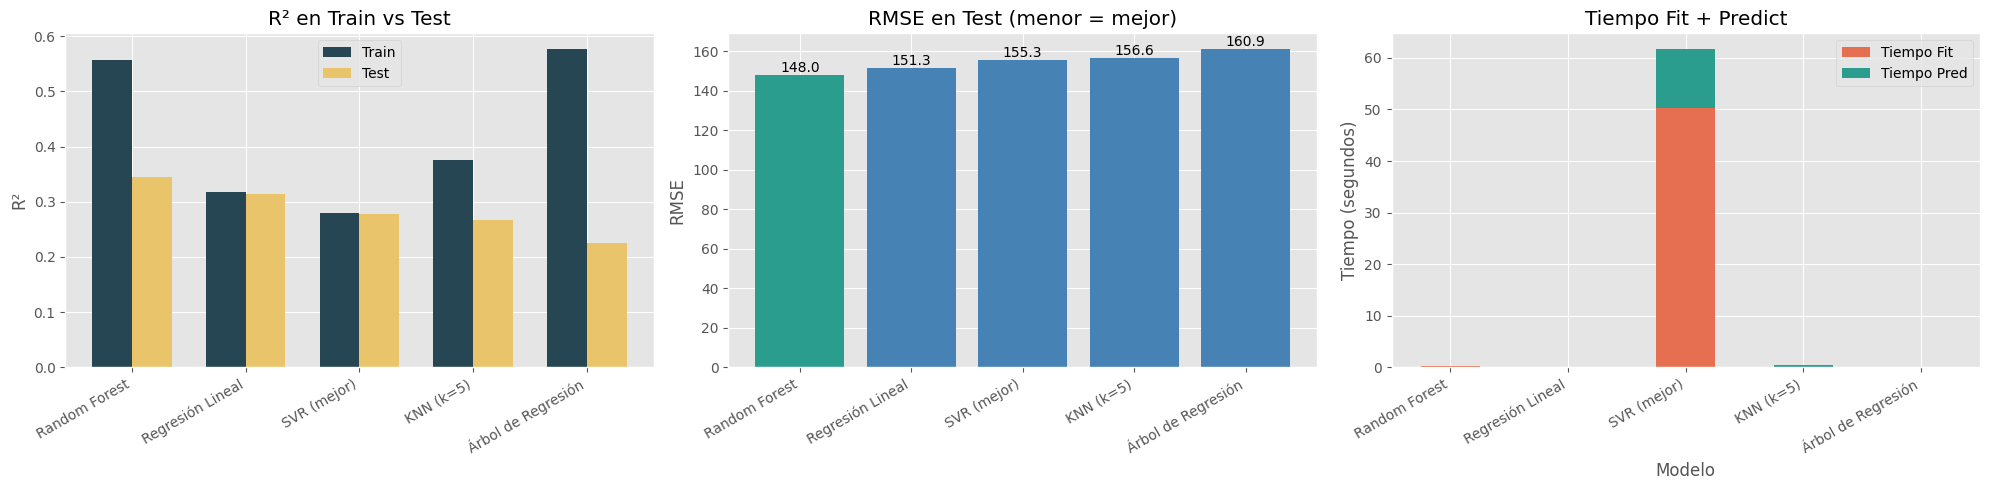

In [48]:
# Visualización: R², RMSE y tiempos por modelo
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

x = np.arange(len(df_reg_results))

# R² Train vs Test
ancho = 0.35
axes[0].bar(x - ancho/2, df_reg_results["R² Train"], ancho, label='Train', color='#264653')
axes[0].bar(x + ancho/2, df_reg_results["R² Test"],  ancho, label='Test',  color='#e9c46a')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_reg_results["Modelo"], rotation=30, ha='right')
axes[0].set_ylabel("R²")
axes[0].set_title("R² en Train vs Test")
axes[0].legend()
axes[0].axhline(0, color='gray', linewidth=0.5)

# RMSE Test
colores_rmse = ['#2a9d8f' if v == df_reg_results["RMSE Test"].min() else 'steelblue'
                for v in df_reg_results["RMSE Test"]]
axes[1].bar(x, df_reg_results["RMSE Test"], color=colores_rmse)
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_reg_results["Modelo"], rotation=30, ha='right')
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE en Test (menor = mejor)")
for i, v in enumerate(df_reg_results["RMSE Test"]):
    axes[1].text(i, v, f"{v:.1f}", ha='center', va='bottom')

# Tiempos apilados
df_t = df_reg_results.set_index("Modelo")[["Tiempo Fit", "Tiempo Pred"]]
df_t.plot(kind='bar', stacked=True, ax=axes[2], color=['#e76f51', '#2a9d8f'])
axes[2].set_ylabel("Tiempo (segundos)")
axes[2].set_title("Tiempo Fit + Predict")
axes[2].set_xticklabels(df_reg_results["Modelo"], rotation=30, ha='right')

plt.tight_layout()
plt.show()

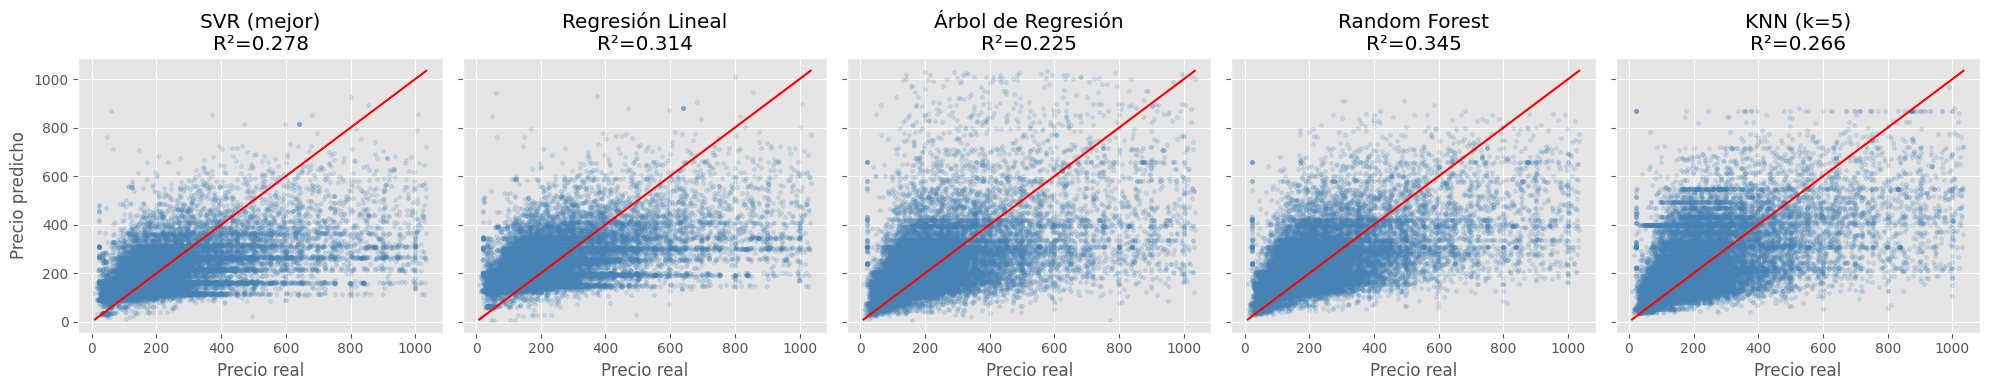

In [49]:
# Predicho vs Real: scatter de los 5 modelos
fig, axes = plt.subplots(1, len(preds_reg), figsize=(4*len(preds_reg), 4), sharex=True, sharey=True)

for ax, (nombre, y_pred_test) in zip(axes, preds_reg.items()):
    ax.scatter(y_test_r, y_pred_test, alpha=0.2, s=8, color='steelblue')
    ax.plot([y_test_r.min(), y_test_r.max()],
            [y_test_r.min(), y_test_r.max()],
            color='red', linewidth=1.5)
    r2_m = r2_score(y_test_r, y_pred_test)
    ax.set_title(f"{nombre}\nR²={r2_m:.3f}")
    ax.set_xlabel("Precio real")

axes[0].set_ylabel("Precio predicho")
plt.tight_layout()
plt.show()

**Análisis comparativo del inciso 12 (resultados reales)**

| # | Modelo              | RMSE Train | RMSE Test | MAE Test | R² Train | R² Test | Gap R² | Tiempo Fit | Tiempo Pred |
|---|---------------------|------------|-----------|----------|----------|---------|--------|------------|-------------|
| 1 | Random Forest       | 121.43     | 147.97    | 101.19   | 0.5566   | 0.3446  | 0.2119 | 0.24 s     | 0.04 s      |
| 2 | Regresión Lineal    | 150.65     | 151.35    | 105.17   | 0.3175   | 0.3143  | 0.0031 | 0.01 s     | 0.000 s     |
| 3 | SVR (mejor)         | 154.67     | 155.32    | 100.27   | 0.2805   | 0.2779  | 0.0026 | 50.26 s    | 11.42 s     |
| 4 | KNN (k=5)           | 144.04     | 156.57    | 108.49   | 0.3760   | 0.2662  | 0.1099 | 0.03 s     | 0.50 s      |
| 5 | Árbol de Regresión  | 118.65     | 160.94    | 107.29   | 0.5766   | 0.2246  | 0.3520 | 0.04 s     | 0.003 s     |

**¿Cuál predice mejor?**
- **Random Forest** es el ganador claro en ambas métricas: R² Test = **0.3446** y RMSE Test = **147.97**, superando a todos los demás.
- **Regresión Lineal** queda en segundo lugar (R² = 0.3143) — sorprendentemente **supera al SVR** con kernel lineal a pesar de que conceptualmente son muy similares. La diferencia se debe a que el SVR usa pérdida ε-insensitive que ignora errores pequeños, mientras que la regresión lineal minimiza directamente el error cuadrático medio (que es exactamente lo que mide R²).
- **SVR** queda tercero (R² = 0.2779). Cumple el objetivo del laboratorio pero no aporta valor frente a la regresión lineal.
- **KNN** y **Árbol** quedan al final, con **Árbol** siendo el peor (R² Test = 0.2246) por su sobreajuste extremo.

**¿Cuál se demoró más en procesar?**
- **SVR es por mucho el más lento**: 50.26 s en fit + 11.42 s en predict (total ~62 s).
- **Random Forest** entrena en 0.24 s — **~210× más rápido que SVR** y con mejor R².
- **Regresión Lineal** es prácticamente instantánea (~10 ms en fit, <1 ms en predict).
- **Árbol** y **KNN** son rápidos en fit, pero KNN tiene predict notablemente más lento (0.50 s) por las distancias.

**Sobreajuste en regresión (gap R² Train − Test):**
- **Árbol de Regresión** está **fuertemente sobreajustado**: gap = **0.3520** (R² Train 0.5766 vs R² Test 0.2246). Memoriza el train pero generaliza mal.
- **Random Forest** tiene **sobreajuste moderado**: gap = 0.2119. Aunque es el mejor en test, su R² Train de 0.5566 vs Test 0.3446 muestra que aún sobreajusta — limitar `max_depth` o `min_samples_leaf` podría ayudar.
- **KNN** muestra sobreajuste leve (gap = 0.1099). k=5 es sensible al ruido local.
- **SVR** y **Regresión Lineal** están perfectamente ajustados (gap ≈ 0.003), pero ambos muestran **desajuste**: explican menos del 32% de la varianza.

**Veredicto final**
- **Mejor para predecir el precio**: **Random Forest** — mejor R² (0.3446), mejor RMSE (147.97), tiempo razonable (0.24 s).
- **Mejor relación costo/desempeño**: **Regresión Lineal** — pierde solo 3 puntos de R² contra RF pero corre en milisegundos.
- **Peor opción**: **Árbol de Regresión sin podar** — peor R² test (0.2246) y el más sobreajustado.
- **SVR no se justifica**: con kernel lineal es equivalente a una regresión lineal pero **~5,000× más lento** y con peor R².

**Comparación con resultados de hojas anteriores (Lab6):**
- Lab6 (regresión sobre `price`): Regresión Lineal RMSE=147.79 R²=0.346, Árbol max_depth=10 RMSE=136.55 R²=0.442, Random Forest RMSE=134.87 R²=0.456.
- En este Lab8 los resultados son ligeramente peores (RF R²=0.345 vs Lab6 R²=0.456). La diferencia probablemente viene de:
  1. **Cap p95** filtró outliers que el Lab6 sí incluyó (o filtró de otra manera).
  2. **Set de features ligeramente distinto** entre labs.
  3. **Árbol del Lab6 estaba podado a max_depth=10**, mientras que aquí se usó sin límite (sobreajusta).
- Aun así, los rankings relativos coinciden: Random Forest es siempre el mejor.